In [1]:
# Step 0: Install Required Libraries
# Run only once if Qiskit or Matplotlib are not installed.
!pip install qiskit matplotlib pylatexenc --quiet

In [2]:
# Step 1: Import Libraries
# Qiskit for circuit creation and simulation
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector

# For better circuit display inside Jupyter
from IPython.display import display

import matplotlib.pyplot as plt

=== Step 1: Creating 3-Qubit Circuit for Teleportation ===


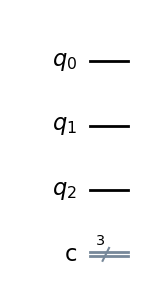

In [3]:
# Step 2: Create a 3-Qubit Quantum Circuit
# q0: Alice's qubit to teleport
# q1: Alice's entangled qubit
# q2: Bob's qubit
# 3 classical bits for measurement
qc = QuantumCircuit(3, 3)

print("=== Step 1: Creating 3-Qubit Circuit for Teleportation ===")
display(qc.draw('mpl'))


=== Step 2: Alice's Qubit Initialized to |+> State ===


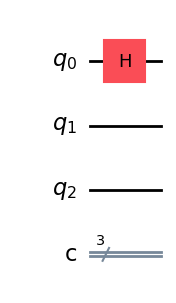

In [4]:
# Step 3: Initialize Alice's Qubit (q0)
# Alice prepares a qubit in |+> state (superposition of |0⟩ and |1⟩)
qc.h(0)

print("=== Step 2: Alice's Qubit Initialized to |+> State ===")
display(qc.draw('mpl'))

# Visualize the Bloch vector (Alice’s qubit before teleportation)
state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)
plt.show()

=== Step 3: Entanglement Created between q1 (Alice) and q2 (Bob) ===


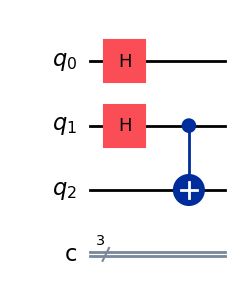

In [5]:
# Step 4: Create Entanglement between Alice (q1) and Bob (q2)
# Alice and Bob share an entangled Bell pair
qc.h(1)       # Put q1 into superposition
qc.cx(1, 2)   # Entangle q1 and q2

print("=== Step 3: Entanglement Created between q1 (Alice) and q2 (Bob) ===")
display(qc.draw('mpl'))

# Visualize the entangled state on Bloch spheres
state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)
plt.show()

=== Step 4: Alice Performs Bell Measurement ===


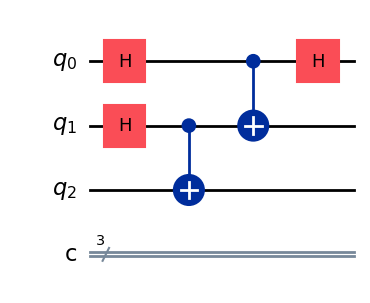

In [6]:
# Step 5: Alice Performs Bell Measurement on q0 and q1
# Alice entangles her message qubit (q0) with her half of the Bell pair (q1)
qc.cx(0, 1)
qc.h(0)

print("=== Step 4: Alice Performs Bell Measurement ===")
display(qc.draw('mpl'))

# Bloch vector visualization before measurement
state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)
plt.show()

=== Step 5: Alice Measures Her Two Qubits ===


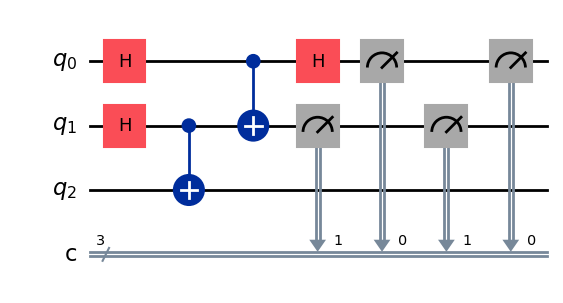

In [8]:
# Step 6: Measure Alice’s Two Qubits
# Measure Alice’s qubits to obtain classical results
qc.measure([0, 1], [0, 1])

print("=== Step 5: Alice Measures Her Two Qubits ===")
display(qc.draw('mpl'))

=== Step 6: Bob Applies Conditional Operations (X/Z) ===


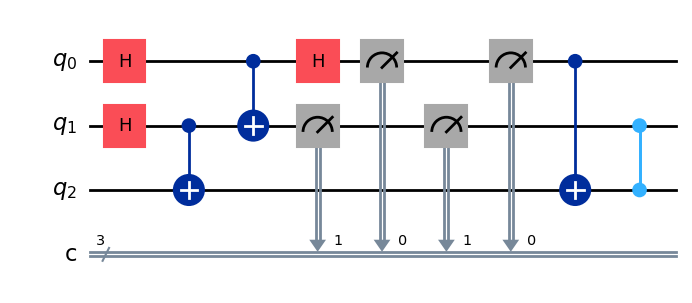

In [9]:
# Step 7: Bob Applies Conditional Operations
# Based on Alice’s classical bits, Bob applies the corrections:
# If Alice’s first bit is 1 → apply X gate
# If Alice’s second bit is 1 → apply Z gate
qc.cx(0, 2)   # Conditional X on q2
qc.cz(1, 2)   # Conditional Z on q2

print("=== Step 6: Bob Applies Conditional Operations (X/Z) ===")
display(qc.draw('mpl'))

=== Step 7: Final Circuit with All Measurements ===


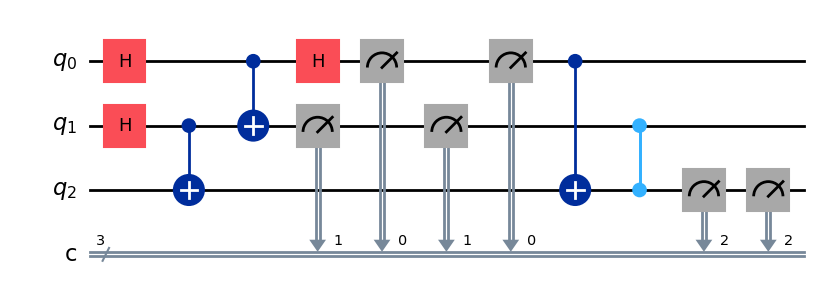

In [11]:
# Step 8: Final Measurement of Bob’s Qubit
# Bob now measures his qubit (q2)
qc.measure(2, 2)

print("=== Step 7: Final Circuit with All Measurements ===")
display(qc.draw('mpl'))